# Repeated K-Fold — real / synthetic / mixed (mean ± 95% CI)

Runs the same 5-fold CV suite `len(SEEDS)` times with different random seeds.
Each seed produces one OOF F1 value per experiment. Results are aggregated as
**mean ± std** and **95% CI** (t-distribution, `df = n_seeds − 1`).

| Pose experiment | Calibration |
|---|---|
| Real pipeline | — |
| Synthetic (Kimodo) | Per-fold (avoids leakage) |
| Mixed | Per-fold (avoids leakage) |


In [1]:
from pathlib import Path
import dataclasses
import sys
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
from IPython.display import Markdown, display

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(
    root for root in candidate_roots
    if (root / 'pose_module').exists() and (root / 'evaluation').exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.classifiers import (
    WindowedDatasetConfig,
    build_classifier_capture_table,
    build_windowed_multimodal_dataset,
)
from evaluation.classifiers import (
    EXPERIMENT_SPECS,
    ModelConfig,
    SplitConfig,
    TrainingConfig,
    run_experiment_suite,
)
from pose_module.robot_emotions.metadata import get_protocol_info
from evaluation.classifiers.metrics import plot_confusion_matrices

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 260)
PROJECT_ROOT

PosixPath('/home/henriquesouza/POSE2IMU-Framework')

## Configuration

- `SEEDS` — random seeds used for repeated K-fold. Each produces one complete 5-fold run.
- All other parameters are identical to `classifiers_pose_experiments.ipynb`.


In [2]:
REAL_OUTPUT_ROOT   = PROJECT_ROOT / 'output' / 'robot_emotions_virtual_imu'
SYNTHETIC_MANIFEST = PROJECT_ROOT / 'output' / 'robot_emotions_kimodo_imu'  / 'virtual_imu_manifest.jsonl'
MIXED_MANIFEST     = PROJECT_ROOT / 'output' / 'robot_emotions_mixed_imu'   / 'mixed_virtual_imu_manifest.jsonl'
ANCHOR_CATALOG     = PROJECT_ROOT / 'output' / 'robot_emotions_kimodo_anchors' / 'kimodo_anchor_catalog.jsonl'

IMU_FEATURE_MODE     = 'acc_euler'
CALIBRATION_FRACTION = 0.1

EXCLUDED_EMOTIONS = {'Anger'}
EXCLUDED_STIMULI  = {}

# Seeds for repeated K-fold — each produces one independent OOF run.
SEEDS = [42, 123, 456, 789, 1234]

DATASET_CONFIG = WindowedDatasetConfig(
    window_size=81,
    overlap=0.5,
    synthetic_variant='raw',
    imu_feature_mode=IMU_FEATURE_MODE,
    selected_sensors=None,
    max_windows_per_capture=None,
    random_state=42,
)
SPLIT_CONFIG = SplitConfig(n_splits=5, random_state=42)
MODEL_CONFIG  = ModelConfig(hidden_dim=128, dropout=0.1, trunk_blocks=2, modality_dropout_p=0.1)
TRAINING_CONFIG = TrainingConfig(
    batch_size=64, max_epochs=10, learning_rate=2e-3, weight_decay=1e-4,
    device='cuda',
    domain_loss_weight=0.1, flat_tag_loss_weight=0.3, emotion_loss_weight=0.6,
    modality_loss_weight=0.10, stimulus_loss_weight=0.3, use_cb_focal=False,
    show_progress=False,
)

REQUESTED_ORDER = [
    'vision_only', 'imu_only_r2r', 'imu_only_s2r', 'imu_only_mixed2r',
    'vision_imu_r2r', 'vision_imu_s2r', 'vision_imu_mixed2r',
]

print('SEEDS:', SEEDS)
print('n_splits:', SPLIT_CONFIG.n_splits)
print('Total runs per experiment:', len(SEEDS), '×', SPLIT_CONFIG.n_splits, 'folds')

SEEDS: [42, 123, 456, 789, 1234]
n_splits: 5
Total runs per experiment: 5 × 5 folds


## Helper functions — data loading & capture tables

Identical to `classifiers_pose_experiments.ipynb`.


In [3]:
def _load_real_manifest_index(real_output_root: Path) -> pd.DataFrame:
    path = real_output_root / 'virtual_imu_manifest.jsonl'
    rows = []
    for line in path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        e = json.loads(line)
        clip_dir = str(Path(e['artifacts']['virtual_imu_npz_path']).parent.parent.parent.resolve())
        rows.append({
            'clip_id':    str(e['clip_id']),
            'domain':     str(e['domain']),
            'user_id':    int(e['user_id']),
            'tag_number': int(e['tag_number']),
            'take_id':    e.get('take_id'),
            'clip_dir':   clip_dir,
        })
    return pd.DataFrame(rows).set_index('clip_id')


def _load_anchor_catalog_index(anchor_catalog_path: Path) -> dict[str, tuple[float, float]]:
    index = {}
    for line in anchor_catalog_path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        e = json.loads(line)
        wid = e.get('window_id') or e.get('prompt_id')
        if wid and 'window' in e and e['window']:
            index[wid] = (float(e['window']['start_sec']), float(e['window']['end_sec']))
    return index


def _build_synthetic_capture_table(manifest_path, real_index, anchor_index, *, pose_kind_filter=None):
    rows = []
    for line in manifest_path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        e = json.loads(line)
        if e.get('status') not in ('ok', 'warning'):
            continue
        pose_kind = e.get('pose_kind', 'synthetic')
        if pose_kind_filter is not None and pose_kind != pose_kind_filter:
            continue

        if pose_kind == 'real':
            artifacts      = e.get('artifacts', {})
            pose3d_npz     = artifacts.get('pose3d_npz_path')
            virtual_imu_npz = artifacts.get('virtual_imu_npz_path')
            uncalibrated_npz = artifacts.get('virtual_imu_geometric_aligned_npz_path')
            ref_clip_id    = str(e['clip_id'])
        else:
            va             = e.get('virtual_imu_artifacts', {})
            pose3d_npz     = va.get('pose3d_npz_path')
            if pose3d_npz is None:
                pose3d_npz = (e.get('constraint_summary') or {}).get('pose3d_source_path')
            virtual_imu_npz  = va.get('virtual_imu_npz_path')
            uncalibrated_npz = va.get('virtual_imu_npz_path')
            ref_clip_id      = str(e.get('reference_clip_id') or e.get('clip_id'))

        if pose3d_npz is None or virtual_imu_npz is None:
            continue
        if not Path(pose3d_npz).exists() or not Path(virtual_imu_npz).exists():
            continue
        if ref_clip_id not in real_index.index:
            continue

        real_row = real_index.loc[ref_clip_id]
        real_imu_ref_path = str(Path(real_row['clip_dir']) / 'imu.npz')
        protocol = get_protocol_info(real_row['domain'], real_row['tag_number']) or {}
        window_id = e.get('window_id')
        real_imu_time_range_sec = anchor_index.get(window_id) if window_id else None
        sample_id = str(e.get('sample_id') or e.get('prompt_id') or e['clip_id'])

        rows.append({
            'clip_id':                            sample_id,
            'reference_clip_id':                  ref_clip_id,
            'domain':                             real_row['domain'],
            'user_id':                            real_row['user_id'],
            'tag_number':                         real_row['tag_number'],
            'take_id':                            real_row['take_id'],
            'emotion':                            str(protocol.get('emotion', '')),
            'modality':                           str(protocol.get('modality', '')),
            'stimulus':                           str(protocol.get('stimulus', 'None')),
            'status':                             str(e.get('status', 'ok')),
            'pose3d_npz_path':                    pose3d_npz,
            'virtual_imu_npz_path':               virtual_imu_npz,
            'virtual_imu_uncalibrated_npz_path':  uncalibrated_npz,
            'real_imu_reference_npz_path':        real_imu_ref_path,
            'virtual_imu_frame_aligned_npz_path': None,
            'clip_dir':                           real_row['clip_dir'],
            'pose_kind':                          pose_kind,
            'quality_report':                     {},
            'real_imu_time_range_sec':            real_imu_time_range_sec,
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df['subject_group']        = df.apply(lambda r: f"{r['domain']}_user_{int(r['user_id']):02d}", axis=1)
    df['flat_tag']             = df.apply(lambda r: f"{r['emotion']}|{r['modality']}|{r['stimulus']}", axis=1)
    df['frame_aligned_available'] = False
    print(f'  real_imu_time_range_sec preenchido: {df["real_imu_time_range_sec"].notna().sum()}/{len(df)}')
    print(f'  virtual_imu_uncalibrated_npz_path preenchido: {df["virtual_imu_uncalibrated_npz_path"].notna().sum()}/{len(df)}')
    return df.reset_index(drop=True)


def _apply_exclusions(df: pd.DataFrame, excluded_emotions: set[str], excluded_stimuli: set[str]) -> pd.DataFrame:
    if df.empty:
        return df
    mask = pd.Series(False, index=df.index)
    if excluded_emotions:
        em = df['emotion'].isin(excluded_emotions)
        if em.any():
            print(f'  Excluindo {int(em.sum())} capturas com emoção em {excluded_emotions}')
        mask |= em
    if excluded_stimuli:
        sm = df['stimulus'].isin(excluded_stimuli)
        if sm.any():
            print(f'  Excluindo {int(sm.sum())} capturas com estímulo em {excluded_stimuli}')
        mask |= sm
    return df.loc[~mask].reset_index(drop=True)


def _sort_suite_summary(summary_df: pd.DataFrame) -> pd.DataFrame:
    order_map = {name: idx for idx, name in enumerate(REQUESTED_ORDER)}
    df = summary_df.copy()
    df['_sort_key'] = df['experiment_name'].astype(str).map(order_map).fillna(len(REQUESTED_ORDER))
    return df.sort_values('_sort_key', kind='stable').drop(columns=['_sort_key']).reset_index(drop=True)


REAL_INDEX   = _load_real_manifest_index(REAL_OUTPUT_ROOT)
ANCHOR_INDEX = _load_anchor_catalog_index(ANCHOR_CATALOG)
print(f'Real manifest index: {len(REAL_INDEX)} clips')
print(f'Anchor catalog index: {len(ANCHOR_INDEX)} windows')

Real manifest index: 89 clips
Anchor catalog index: 3725 windows


## Helper functions — per-fold calibration

Identical to `classifiers_pose_experiments.ipynb`.


In [4]:
from evaluation.classifiers.experiments import (
    build_subject_group_splits,
    run_single_experiment,
    _aggregate_oof_report,
    _build_oof_summary,
)
from evaluation.classifiers.metrics import (
    build_scored_class_ids,
    build_support_report,
    compute_domain_gap_summary,
    suite_results_frame,
    PRIMARY_HEADS,
)
from pose_module.processing.imu_calibration import (
    build_calibration_reference_matrix,
    calibrate_virtual_imu_sequence,
)
from evaluation.classifiers.features import build_imu_feature_tensor
from evaluation.tsne import segment_signal_windows


def _build_train_real_imu_matrix(
    dataset_bundle: dict,
    train_capture_ids: set[str],
    *,
    calibration_fraction: float = 1.0,
) -> np.ndarray:
    capture_table = dataset_bundle['capture_table']
    train_rows = capture_table[capture_table['clip_id'].isin(train_capture_ids)]
    seen_paths: set[str] = set()
    clip_npz_paths = []
    for _, row in train_rows.iterrows():
        ref_path = row.get('real_imu_reference_npz_path')
        if not ref_path or not Path(ref_path).exists():
            candidate = Path(row['clip_dir']) / 'imu.npz'
            if not candidate.exists():
                continue
            ref_path = str(candidate)
        if ref_path in seen_paths:
            continue
        seen_paths.add(ref_path)
        clip_npz_paths.append(ref_path)
    if not clip_npz_paths:
        raise RuntimeError('No training clip with a valid imu.npz found.')
    return build_calibration_reference_matrix(
        clip_npz_paths=clip_npz_paths,
        target_sensor_names=dataset_bundle['selected_sensors'],
        signal_mode='acc',
        calibration_fraction=calibration_fraction,
    )


def _recalibrate_synthetic_windows(
    dataset_bundle: dict,
    train_indices: np.ndarray,
) -> np.ndarray:
    import tempfile, os
    from pose_module.interfaces import VirtualIMUSequence

    metadata         = dataset_bundle['metadata']
    capture_table    = dataset_bundle['capture_table']
    imu_synthetic    = np.array(dataset_bundle['imu_synthetic_windows'], dtype=np.float32)
    imu_feature_mode = dataset_bundle['imu_feature_mode']
    selected_sensors = dataset_bundle['selected_sensors']
    cfg              = dataset_bundle['config']

    train_capture_ids = set(metadata.iloc[train_indices]['capture_id'].astype(str).tolist())
    real_matrix = _build_train_real_imu_matrix(
        dataset_bundle, train_capture_ids, calibration_fraction=CALIBRATION_FRACTION
    )

    tmp = tempfile.NamedTemporaryFile(suffix='.npz', delete=False)
    tmp.close()
    try:
        np.savez(tmp.name,
                 acc=real_matrix.reshape(real_matrix.shape[0], len(selected_sensors), -1),
                 sensor_names=np.array(selected_sensors))
        cap_idx = capture_table.set_index('clip_id')

        for capture_id, window_indices in metadata.groupby('capture_id').groups.items():
            capture_id = str(capture_id)
            if capture_id not in cap_idx.index:
                continue
            cap_row = cap_idx.loc[capture_id]
            uncalibrated_path = cap_row.get('virtual_imu_uncalibrated_npz_path')
            if not uncalibrated_path or pd.isna(uncalibrated_path) or not Path(uncalibrated_path).exists():
                continue

            with np.load(uncalibrated_path, allow_pickle=True) as payload:
                raw_acc          = np.asarray(payload['acc'],            dtype=np.float32)
                raw_gyro         = np.asarray(payload['gyro'],           dtype=np.float32)
                timestamps_sec   = np.asarray(payload['timestamps_sec'], dtype=np.float32)
                sensor_names_raw = [str(v) for v in np.asarray(payload['sensor_names']).tolist()]

            sel_indices = [sensor_names_raw.index(s) for s in selected_sensors if s in sensor_names_raw]
            if len(sel_indices) != len(selected_sensors):
                continue
            acc_sel  = raw_acc[:,  sel_indices, :]
            gyro_sel = raw_gyro[:, sel_indices, :]

            seq = VirtualIMUSequence(
                clip_id=capture_id, fps=None, sensor_names=selected_sensors,
                acc=acc_sel, gyro=gyro_sel, timestamps_sec=timestamps_sec, source='uncalibrated',
            )
            result = calibrate_virtual_imu_sequence(seq, real_imu_reference_path=tmp.name, signal_mode='acc')
            calibrated_acc = np.asarray(result['virtual_imu_sequence'].acc, dtype=np.float32)

            imu_features = build_imu_feature_tensor(
                calibrated_acc, gyro_sel, timestamps_sec, feature_mode=imu_feature_mode
            )
            window_bundle = segment_signal_windows(
                imu_features['values'],
                window_type='n_samples',
                window_size=int(cfg.window_size),
                stride_or_overlap_mode='overlap',
                overlap=float(cfg.overlap),
            )
            new_windows    = np.asarray(window_bundle['windows'], dtype=np.float32)
            idx_array      = np.asarray(window_indices, dtype=np.int64)
            n_replace      = min(len(idx_array), new_windows.shape[0])
            imu_synthetic[idx_array[:n_replace]] = new_windows[:n_replace]
    finally:
        os.unlink(tmp.name)

    return imu_synthetic

## Repeated K-Fold runner

`_run_experiment_for_seed` runs one complete K-fold CV with a single seed.
`_run_repeated_kfold` loops over `SEEDS` and collects per-seed OOF results.

Each seed creates its own `SplitConfig(random_state=seed)` via `dataclasses.replace`,
leaving every other hyperparameter unchanged.


In [5]:
import torch
import pickle

CHECKPOINT_DIR = PROJECT_ROOT / 'output' / 'repeated_kfold_checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Checkpoint dir: {CHECKPOINT_DIR}')


def _ckpt_stem(label: str, seed: int, experiment_name: str, fold_id: int) -> Path:
    safe_label = label.replace(' ', '_')
    return CHECKPOINT_DIR / f'{safe_label}__seed{seed}__{experiment_name}__fold{fold_id}'


def _save_fold_result(result: dict, label: str, seed: int) -> None:
    stem = _ckpt_stem(label, seed, result['experiment_name'], result['split_id'])
    # Metrics and history are JSON-serialisable; test_predictions contains numpy arrays.
    payload = {
        'experiment_name':  result['experiment_name'],
        'split_id':         result['split_id'],
        'spec':             result['spec'],
        'metrics':          result['metrics'],
        'history':          result['history'],
        'train_metrics':    result['train_metrics'],
        'val_metrics':      result['val_metrics'],
    }
    with open(str(stem) + '.json', 'w', encoding='utf-8') as f:
        json.dump(payload, f)
    # test_predictions has numpy arrays — use pickle for those.
    with open(str(stem) + '_preds.pkl', 'wb') as f:
        pickle.dump(result['test_predictions'], f)


def _load_fold_result(label: str, seed: int, experiment_name: str, fold_id: int) -> dict | None:
    stem = _ckpt_stem(label, seed, experiment_name, fold_id)
    json_path = Path(str(stem) + '.json')
    pkl_path  = Path(str(stem) + '_preds.pkl')
    if not json_path.exists() or not pkl_path.exists():
        return None
    with open(json_path, encoding='utf-8') as f:
        payload = json.load(f)
    with open(pkl_path, 'rb') as f:
        test_predictions = pickle.load(f)
    payload['test_predictions'] = test_predictions
    return payload


def _run_experiment_for_seed(
    label: str,
    captures_df: pd.DataFrame,
    seed: int,
    *,
    use_fold_calibration: bool = False,
) -> dict:
    split_cfg   = dataclasses.replace(SPLIT_CONFIG,   random_state=seed)
    dataset_cfg = dataclasses.replace(DATASET_CONFIG, random_state=seed)

    dataset_bundle = build_windowed_multimodal_dataset(
        REAL_OUTPUT_ROOT, config=dataset_cfg, captures_df=captures_df
    )
    experiment_names = list(EXPERIMENT_SPECS.keys())

    if not use_fold_calibration:
        splits = build_subject_group_splits(dataset_bundle['metadata'], config=split_cfg)
        support_report = build_support_report(
            dataset_bundle['metadata'],
            dataset_bundle['label_encoders'],
            group_column=str(split_cfg.group_column),
            min_subject_groups=int(split_cfg.min_subject_groups_per_class),
        )
        scored_class_ids = build_scored_class_ids(support_report, head_names=PRIMARY_HEADS)

        results = []
        for split in splits:
            split_ctx = {**split, 'num_splits': len(splits)}
            for experiment_name in experiment_names:
                fold_id  = int(split['split_id'])
                cached   = _load_fold_result(label, seed, experiment_name, fold_id)
                if cached is not None:
                    print(f'    [cache] {experiment_name} fold {fold_id+1} — carregado do disco')
                    results.append(cached)
                    continue
                result = run_single_experiment(
                    dataset_bundle,
                    experiment_name=experiment_name,
                    split=split_ctx,
                    model_config=MODEL_CONFIG,
                    training_config=TRAINING_CONFIG,
                    scored_class_ids=scored_class_ids,
                )
                _save_fold_result(result, label, seed)
                results.append(result)

        oof_reports = {
            exp: _aggregate_oof_report(
                [r for r in results if r['experiment_name'] == exp],
                label_encoders=dataset_bundle['label_encoders'],
                scored_class_ids=scored_class_ids,
            )
            for exp in experiment_names
        }
        oof_summary = _build_oof_summary(
            oof_reports,
            support_report=support_report,
            primary_head=str(split_cfg.primary_head),
        )
        suite_result = {
            'results':            results,
            'results_frame':      suite_results_frame(results),
            'summary':            oof_summary,
            'oof_reports':        oof_reports,
            'support_report':     support_report,
            'domain_gap_summary': compute_domain_gap_summary(oof_summary),
            'splits':             splits,
        }

    else:
        # Synthetic / mixed: recalibrate per fold to avoid leakage.
        splits = build_subject_group_splits(dataset_bundle['metadata'], config=split_cfg)
        support_report = build_support_report(
            dataset_bundle['metadata'],
            dataset_bundle['label_encoders'],
            group_column=str(split_cfg.group_column),
            min_subject_groups=int(split_cfg.min_subject_groups_per_class),
        )
        scored_class_ids = build_scored_class_ids(support_report, head_names=PRIMARY_HEADS)

        results = []
        for split in splits:
            fold_id       = int(split['split_id'])
            train_indices = np.asarray(split['train_indices'], dtype=np.int64)
            split_ctx     = {**split, 'num_splits': len(splits)}

            # Check if all experiments for this fold are already cached.
            cached_for_fold = {
                exp: _load_fold_result(label, seed, exp, fold_id)
                for exp in experiment_names
            }
            all_cached = all(v is not None for v in cached_for_fold.values())

            if all_cached:
                print(f'    [cache] Fold {fold_id+1}/{len(splits)} — todos experimentos carregados do disco')
                results.extend(cached_for_fold.values())
                continue

            print(f'    Fold {fold_id+1}/{len(splits)}: recalibrando IMU sintético...')
            recalibrated = _recalibrate_synthetic_windows(dataset_bundle, train_indices)
            fold_bundle  = {**dataset_bundle, 'imu_synthetic_windows': recalibrated}

            for experiment_name in experiment_names:
                cached = cached_for_fold[experiment_name]
                if cached is not None:
                    print(f'    [cache] {experiment_name} fold {fold_id+1} — carregado do disco')
                    results.append(cached)
                    continue
                result = run_single_experiment(
                    fold_bundle,
                    experiment_name=experiment_name,
                    split=split_ctx,
                    model_config=MODEL_CONFIG,
                    training_config=TRAINING_CONFIG,
                    scored_class_ids=scored_class_ids,
                )
                _save_fold_result(result, label, seed)
                results.append(result)

        oof_reports = {
            exp: _aggregate_oof_report(
                [r for r in results if r['experiment_name'] == exp],
                label_encoders=dataset_bundle['label_encoders'],
                scored_class_ids=scored_class_ids,
            )
            for exp in experiment_names
        }
        oof_summary = _build_oof_summary(
            oof_reports,
            support_report=support_report,
            primary_head=str(split_cfg.primary_head),
        )
        suite_result = {
            'results':            results,
            'results_frame':      suite_results_frame(results),
            'summary':            oof_summary,
            'oof_reports':        oof_reports,
            'support_report':     support_report,
            'domain_gap_summary': compute_domain_gap_summary(oof_summary),
            'splits':             splits,
        }

    return {
        'label':          label,
        'seed':           seed,
        'dataset_bundle': dataset_bundle,
        'suite_result':   suite_result,
    }


def _run_repeated_kfold(
    label: str,
    captures_df: pd.DataFrame,
    *,
    use_fold_calibration: bool = False,
) -> dict:
    captures_df = _apply_exclusions(captures_df.copy(), EXCLUDED_EMOTIONS, EXCLUDED_STIMULI)
    seed_results = []

    for i, seed in enumerate(SEEDS):
        print(f"\n{'='*60}")
        print(f"  {label}  —  seed {seed}  ({i+1}/{len(SEEDS)})")
        print(f"{'='*60}")
        result = _run_experiment_for_seed(
            label, captures_df, seed, use_fold_calibration=use_fold_calibration
        )
        seed_results.append(result)
        short = _sort_suite_summary(result['suite_result']['summary'])
        display(short[['experiment_name', 'global_score_macro_f1_mean', 'global_score_weighted_macro_f1', 'emotion_macro_f1']].head(10))

    print(f"\nConcluído: {len(seed_results)} seeds × {SPLIT_CONFIG.n_splits} folds para '{label}'")
    return {'label': label, 'seed_results': seed_results}

Checkpoint dir: /home/henriquesouza/POSE2IMU-Framework/output/repeated_kfold_checkpoints


## CI aggregation and plotting


In [6]:
CI_METRICS = [
    'emotion_macro_f1',
    'modality_macro_f1',
    'stimulus_macro_f1',
    'global_score_macro_f1_mean',
    'global_score_weighted_macro_f1',
]


def compute_ci_summary(repeated_result: dict, metric: str = 'emotion_macro_f1') -> pd.DataFrame:
    """
    Aggregate per-seed OOF scores into mean ± std and 95% CI.
    Uses t-distribution with df = n_seeds - 1 (appropriate for small n).
    """
    exp_scores: dict[str, list[float]] = {}
    for sr in repeated_result['seed_results']:
        for _, row in sr['suite_result']['summary'].iterrows():
            exp = str(row['experiment_name'])
            val = row.get(metric)
            if val is not None and not pd.isna(val):
                exp_scores.setdefault(exp, []).append(float(val))

    order_map = {name: i for i, name in enumerate(REQUESTED_ORDER)}
    rows = []
    for exp_name, scores in sorted(exp_scores.items(), key=lambda x: order_map.get(x[0], 999)):
        n   = len(scores)
        arr = np.array(scores)
        mean = float(np.mean(arr))
        std  = float(np.std(arr, ddof=1)) if n > 1 else 0.0
        sem  = std / np.sqrt(n) if n > 1 else 0.0
        ci_half = float(scipy_stats.t.ppf(0.975, df=n - 1) * sem) if n > 1 else 0.0
        rows.append({
            'experiment_name': exp_name,
            'mean':            round(mean, 4),
            'std':             round(std,  4),
            'ci95_half':       round(ci_half, 4),
            'formatted':       f'{mean:.3f} ± {ci_half:.3f}',
            'n_seeds':         n,
            '_scores':         scores,
        })
    return pd.DataFrame(rows)


def build_full_ci_table(repeated_result: dict) -> pd.DataFrame:
    """
    Multi-metric CI table for all CI_METRICS.
    Each column shows 'mean ± 95% CI' for one metric.
    """
    base = compute_ci_summary(repeated_result, metric=CI_METRICS[0])
    result = base[['experiment_name', 'n_seeds', 'formatted']].rename(
        columns={'formatted': CI_METRICS[0]}
    )
    for metric in CI_METRICS[1:]:
        df = compute_ci_summary(repeated_result, metric=metric)[['experiment_name', 'formatted']]
        df = df.rename(columns={'formatted': metric})
        result = result.merge(df, on='experiment_name', how='left')
    return result


def plot_ci_bar(repeated_results: list[dict], metric: str = 'emotion_macro_f1') -> None:
    """Grouped bar chart with 95% CI error bars — one group per classifier."""
    n_groups = len(REQUESTED_ORDER)
    n_exp    = len(repeated_results)
    bar_w    = 0.8 / n_exp
    x        = np.arange(n_groups)
    colors   = ['#2196F3', '#FF5722', '#4CAF50']

    fig, ax = plt.subplots(figsize=(14, 5))
    for i, rr in enumerate(repeated_results):
        ci_df = compute_ci_summary(rr, metric=metric).set_index('experiment_name')
        means    = [ci_df.loc[e, 'mean']      if e in ci_df.index else 0.0 for e in REQUESTED_ORDER]
        ci_halfs = [ci_df.loc[e, 'ci95_half'] if e in ci_df.index else 0.0 for e in REQUESTED_ORDER]
        offset   = (i - n_exp / 2 + 0.5) * bar_w
        ax.bar(
            x + offset, means, bar_w * 0.9,
            label=rr['label'], color=colors[i % len(colors)], alpha=0.8,
            yerr=ci_halfs, capsize=4, error_kw={'linewidth': 1.5},
        )

    n_seeds = len(repeated_results[0]['seed_results'])
    ax.set_xticks(x)
    ax.set_xticklabels(REQUESTED_ORDER, rotation=30, ha='right')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.set_title(f'{metric}  —  mean ± 95% CI  ({n_seeds} seeds × {SPLIT_CONFIG.n_splits} folds)')
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_seed_boxplot(repeated_results: list[dict], metric: str = 'emotion_macro_f1') -> None:
    """Boxplot of per-seed OOF scores — one panel per pose experiment."""
    fig, axes = plt.subplots(1, len(repeated_results), figsize=(6 * len(repeated_results), 5), sharey=True)
    if len(repeated_results) == 1:
        axes = [axes]

    for ax, rr in zip(axes, repeated_results):
        ci_df  = compute_ci_summary(rr, metric=metric).set_index('experiment_name')
        data   = [ci_df.loc[e, '_scores'] for e in REQUESTED_ORDER if e in ci_df.index]
        labels = [e for e in REQUESTED_ORDER if e in ci_df.index]
        ax.boxplot(data, tick_labels=labels, vert=True)
        ax.set_title(rr['label'])
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_ylabel(metric)
        ax.set_ylim(0, 1)

    fig.suptitle(f'{metric}  —  distribuição por seed', y=1.02)
    plt.tight_layout()
    plt.show()

## Build capture tables (once — reused across all seeds)


In [7]:
print('--- Real pipeline captures ---')
CAPTURES_REAL = build_classifier_capture_table(REAL_OUTPUT_ROOT)
print(f'{len(CAPTURES_REAL)} clips')

print('\n--- Synthetic (Kimodo) captures ---')
CAPTURES_SYNTHETIC = _build_synthetic_capture_table(
    SYNTHETIC_MANIFEST, REAL_INDEX, ANCHOR_INDEX, pose_kind_filter='synthetic'
)
print(f'{len(CAPTURES_SYNTHETIC)} clips')

print('\n--- Mixed captures ---')
CAPTURES_MIXED = _build_synthetic_capture_table(
    MIXED_MANIFEST, REAL_INDEX, ANCHOR_INDEX, pose_kind_filter=None
)
print(f'{len(CAPTURES_MIXED)} clips')

--- Real pipeline captures ---
80 clips

--- Synthetic (Kimodo) captures ---
  real_imu_time_range_sec preenchido: 3725/3725
  virtual_imu_uncalibrated_npz_path preenchido: 3725/3725
3725 clips

--- Mixed captures ---
  real_imu_time_range_sec preenchido: 3722/3811
  virtual_imu_uncalibrated_npz_path preenchido: 3811/3811
3811 clips


In [8]:
def _print_dataset_metrics(
    label: str,
    captures_df: pd.DataFrame,
    dataset_config: WindowedDatasetConfig,
    *,
    reference_n_captures: int | None = None,
    reference_n_windows: int | None = None,
) -> dict:
    """
    Print summary metrics for a given experiment type before running K-fold.
    Returns a dict with n_total and total_windows for use as reference baseline.
    """
    df = captures_df.copy()

    # --- Capture counts ---
    n_total   = len(df)
    n_real    = int((df['pose_kind'] == 'real').sum()) if 'pose_kind' in df.columns else n_total
    n_virtual = n_total - n_real

    # --- Per-capture duration and frequency from real IMU .npz ---
    durations_sec  = []
    frequencies_hz = []
    for _, row in df.iterrows():
        imu_path = row.get('real_imu_reference_npz_path') or str(Path(row['clip_dir']) / 'imu.npz')
        try:
            with np.load(imu_path, allow_pickle=True) as p:
                ts = np.asarray(p['timestamps_sec'], dtype=np.float32)
            if len(ts) > 1:
                dur  = float(ts[-1] - ts[0])
                freq = float((len(ts) - 1) / dur) if dur > 0 else 0.0
                durations_sec.append(dur)
                frequencies_hz.append(freq)
        except Exception:
            pass

    mean_dur  = float(np.mean(durations_sec))  if durations_sec  else float('nan')
    mean_freq = float(np.mean(frequencies_hz)) if frequencies_hz else float('nan')

    # --- Window count estimate ---
    stride        = int(dataset_config.window_size * (1.0 - dataset_config.overlap))
    total_windows = 0
    for dur in durations_sec:
        n_frames = int(dur * mean_freq)
        if n_frames >= dataset_config.window_size:
            total_windows += max(0, (n_frames - dataset_config.window_size) // stride + 1)
    window_dur_sec = dataset_config.window_size / mean_freq if mean_freq > 0 else float('nan')

    # --- Relative size vs real pipeline ---
    cap_ratio = n_total / reference_n_captures if reference_n_captures else None
    win_ratio = total_windows / reference_n_windows if reference_n_windows else None

    print(f"\n{'='*55}")
    print(f"  Dataset Metrics — {label}")
    print(f"{'='*55}")
    print(f"  Capturas totais      : {n_total}", end="")
    if cap_ratio is not None:
        print(f"  ({cap_ratio:.1f}× real)", end="")
    print()
    print(f"  Capturas reais       : {n_real}")
    print(f"  Capturas virtuais    : {n_virtual}")
    if durations_sec:
        print(f"  Duração média (s)    : {mean_dur:.2f}  (min={min(durations_sec):.2f}, max={max(durations_sec):.2f})")
    else:
        print(f"  Duração média (s)    : N/A")
    print(f"  Frequência média (Hz): {mean_freq:.1f}")
    print(f"  Tamanho da janela    : {dataset_config.window_size} amostras  ≈ {window_dur_sec:.2f} s")
    print(f"  Sobreposição         : {dataset_config.overlap:.0%}")
    print(f"  Nº janelas estimado  : {total_windows}", end="")
    if win_ratio is not None:
        print(f"  ({win_ratio:.1f}× real)", end="")
    print()
    print(f"{'='*55}\n")

    return {'n_captures': n_total, 'n_windows': total_windows}


print("\n--- Métricas por tipo de experimento ---")
ref = _print_dataset_metrics('Real pipeline',      CAPTURES_REAL,      DATASET_CONFIG)
_print_dataset_metrics('Synthetic (Kimodo)', CAPTURES_SYNTHETIC, DATASET_CONFIG,
                       reference_n_captures=ref['n_captures'], reference_n_windows=ref['n_windows'])
_print_dataset_metrics('Mixed',              CAPTURES_MIXED,     DATASET_CONFIG,
                       reference_n_captures=ref['n_captures'], reference_n_windows=ref['n_windows'])


--- Métricas por tipo de experimento ---

  Dataset Metrics — Real pipeline
  Capturas totais      : 80
  Capturas reais       : 80
  Capturas virtuais    : 0
  Duração média (s)    : 110.14  (min=51.79, max=245.69)
  Frequência média (Hz): 64.3
  Tamanho da janela    : 81 amostras  ≈ 1.26 s
  Sobreposição         : 50%
  Nº janelas estimado  : 14031


  Dataset Metrics — Synthetic (Kimodo)
  Capturas totais      : 3725  (46.6× real)
  Capturas reais       : 0
  Capturas virtuais    : 3725
  Duração média (s)    : 128.38  (min=44.78, max=476.07)
  Frequência média (Hz): 56.7
  Tamanho da janela    : 81 amostras  ≈ 1.43 s
  Sobreposição         : 50%
  Nº janelas estimado  : 671961  (47.9× real)


  Dataset Metrics — Mixed
  Capturas totais      : 3811  (47.6× real)
  Capturas reais       : 89
  Capturas virtuais    : 3722
  Duração média (s)    : 128.17  (min=44.78, max=476.07)
  Frequência média (Hz): 56.8
  Tamanho da janela    : 81 amostras  ≈ 1.43 s
  Sobreposição         : 50%
  

{'n_captures': 3811, 'n_windows': 687665}

---
## Experiment 1 — Real pipeline  ×  5 seeds


In [9]:
REPEATED_REAL = _run_repeated_kfold(
    'real_pose',
    CAPTURES_REAL,
    use_fold_calibration=False,
)

  Excluindo 1 capturas com emoção em {'Anger'}

  real_pose  —  seed 42  (1/5)
    [cache] vision_only fold 1 — carregado do disco
    [cache] imu_only_r2r fold 1 — carregado do disco
    [cache] imu_only_s2r fold 1 — carregado do disco
    [cache] imu_only_mixed2r fold 1 — carregado do disco
    [cache] vision_imu_r2r fold 1 — carregado do disco
    [cache] vision_imu_s2r fold 1 — carregado do disco
    [cache] vision_imu_mixed2r fold 1 — carregado do disco
    [cache] vision_only fold 2 — carregado do disco
    [cache] imu_only_r2r fold 2 — carregado do disco
    [cache] imu_only_s2r fold 2 — carregado do disco
    [cache] imu_only_mixed2r fold 2 — carregado do disco
    [cache] vision_imu_r2r fold 2 — carregado do disco
    [cache] vision_imu_s2r fold 2 — carregado do disco
    [cache] vision_imu_mixed2r fold 2 — carregado do disco
    [cache] vision_only fold 3 — carregado do disco
    [cache] imu_only_r2r fold 3 — carregado do disco
    [cache] imu_only_s2r fold 3 — carregado do d

,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,emotion_macro_f1
0,vision_only,0.618077,0.573406,0.439395
1,imu_only_r2r,0.534595,0.499975,0.396114
2,imu_only_s2r,0.445631,0.402725,0.274005
3,imu_only_mixed2r,0.534634,0.495166,0.376764
4,vision_imu_r2r,0.561989,0.519054,0.390247
5,vision_imu_s2r,0.585541,0.538606,0.397798
6,vision_imu_mixed2r,0.604416,0.561869,0.434228



  real_pose  —  seed 123  (2/5)
    [cache] vision_only fold 1 — carregado do disco
    [cache] imu_only_r2r fold 1 — carregado do disco
    [cache] imu_only_s2r fold 1 — carregado do disco
    [cache] imu_only_mixed2r fold 1 — carregado do disco
    [cache] vision_imu_r2r fold 1 — carregado do disco
    [cache] vision_imu_s2r fold 1 — carregado do disco
    [cache] vision_imu_mixed2r fold 1 — carregado do disco
    [cache] vision_only fold 2 — carregado do disco
    [cache] imu_only_r2r fold 2 — carregado do disco
    [cache] imu_only_s2r fold 2 — carregado do disco
    [cache] imu_only_mixed2r fold 2 — carregado do disco
    [cache] vision_imu_r2r fold 2 — carregado do disco
    [cache] vision_imu_s2r fold 2 — carregado do disco
    [cache] vision_imu_mixed2r fold 2 — carregado do disco
    [cache] vision_only fold 3 — carregado do disco
    [cache] imu_only_r2r fold 3 — carregado do disco
    [cache] imu_only_s2r fold 3 — carregado do disco
    [cache] imu_only_mixed2r fold 3 — car

,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,emotion_macro_f1
0,vision_only,0.565531,0.516466,0.369272
1,imu_only_r2r,0.537958,0.502947,0.397914
2,imu_only_s2r,0.455509,0.412874,0.284970
3,imu_only_mixed2r,0.538107,0.503001,0.397686
4,vision_imu_r2r,0.577925,0.526810,0.373463
5,vision_imu_s2r,0.560437,0.509941,0.358451
6,vision_imu_mixed2r,0.602606,0.558758,0.427213



  real_pose  —  seed 456  (3/5)
    [cache] vision_only fold 1 — carregado do disco
    [cache] imu_only_r2r fold 1 — carregado do disco
    [cache] imu_only_s2r fold 1 — carregado do disco
    [cache] imu_only_mixed2r fold 1 — carregado do disco
    [cache] vision_imu_r2r fold 1 — carregado do disco
    [cache] vision_imu_s2r fold 1 — carregado do disco
    [cache] vision_imu_mixed2r fold 1 — carregado do disco
    [cache] vision_only fold 2 — carregado do disco
    [cache] imu_only_r2r fold 2 — carregado do disco
    [cache] imu_only_s2r fold 2 — carregado do disco
    [cache] imu_only_mixed2r fold 2 — carregado do disco
    [cache] vision_imu_r2r fold 2 — carregado do disco
    [cache] vision_imu_s2r fold 2 — carregado do disco
    [cache] vision_imu_mixed2r fold 2 — carregado do disco
    [cache] vision_only fold 3 — carregado do disco
    [cache] imu_only_r2r fold 3 — carregado do disco
    [cache] imu_only_s2r fold 3 — carregado do disco
    [cache] imu_only_mixed2r fold 3 — car

...


  real_pose  —  seed 789  (4/5)
    [cache] vision_only fold 1 — carregado do disco
    [cache] imu_only_r2r fold 1 — carregado do disco
    [cache] imu_only_s2r fold 1 — carregado do disco
    [cache] imu_only_mixed2r fold 1 — carregado do disco
    [cache] vision_imu_r2r fold 1 — carregado do disco
    [cache] vision_imu_s2r fold 1 — carregado do disco
    [cache] vision_imu_mixed2r fold 1 — carregado do disco
    [cache] vision_only fold 2 — carregado do disco
    [cache] imu_only_r2r fold 2 — carregado do disco
    [cache] imu_only_s2r fold 2 — carregado do disco
    [cache] imu_only_mixed2r fold 2 — carregado do disco
    [cache] vision_imu_r2r fold 2 — carregado do disco
    [cache] vision_imu_s2r fold 2 — carregado do disco
    [cache] vision_imu_mixed2r fold 2 — carregado do disco
    [cache] vision_only fold 3 — carregado do disco
    [cache] imu_only_r2r fold 3 — carregado do disco
    [cache] imu_only_s2r fold 3 — carregado do disco
    [cache] imu_only_mixed2r fold 3 — car

,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,emotion_macro_f1
0,vision_only,0.586813,0.546501,0.425566
1,imu_only_r2r,0.536073,0.501224,0.396677
2,imu_only_s2r,0.425098,0.381816,0.251972
3,imu_only_mixed2r,0.530254,0.493880,0.384761
4,vision_imu_r2r,0.569746,0.522084,0.379097
5,vision_imu_s2r,0.547300,0.495059,0.338336
6,vision_imu_mixed2r,0.644865,0.606116,0.489867



  real_pose  —  seed 1234  (5/5)
    [cache] vision_only fold 1 — carregado do disco
    [cache] imu_only_r2r fold 1 — carregado do disco
    [cache] imu_only_s2r fold 1 — carregado do disco
    [cache] imu_only_mixed2r fold 1 — carregado do disco
    [cache] vision_imu_r2r fold 1 — carregado do disco
    [cache] vision_imu_s2r fold 1 — carregado do disco
    [cache] vision_imu_mixed2r fold 1 — carregado do disco
    [cache] vision_only fold 2 — carregado do disco
    [cache] imu_only_r2r fold 2 — carregado do disco
    [cache] imu_only_s2r fold 2 — carregado do disco
    [cache] imu_only_mixed2r fold 2 — carregado do disco
    [cache] vision_imu_r2r fold 2 — carregado do disco
    [cache] vision_imu_s2r fold 2 — carregado do disco
    [cache] vision_imu_mixed2r fold 2 — carregado do disco
    [cache] vision_only fold 3 — carregado do disco
    [cache] imu_only_r2r fold 3 — carregado do disco
    [cache] imu_only_s2r fold 3 — carregado do disco
    [cache] imu_only_mixed2r fold 3 — ca

,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,emotion_macro_f1
0,vision_only,0.586591,0.539612,0.398676
1,imu_only_r2r,0.524425,0.486213,0.371577
2,imu_only_s2r,0.411314,0.365019,0.226134
3,imu_only_mixed2r,0.549921,0.511866,0.397702
4,vision_imu_r2r,0.578992,0.537825,0.414325
5,vision_imu_s2r,0.568690,0.519716,0.372795
6,vision_imu_mixed2r,0.586700,0.540272,0.400989



Concluído: 5 seeds × 5 folds para 'real_pose'


---
## Experiment 2 — Synthetic (Kimodo)  ×  5 seeds


In [10]:
REPEATED_SYNTHETIC = _run_repeated_kfold(
    'synthetic_pose',
    CAPTURES_SYNTHETIC,
    use_fold_calibration=True,
)

  Excluindo 12 capturas com emoção em {'Anger'}

  synthetic_pose  —  seed 42  (1/5)
    [cache] Fold 1/5 — todos experimentos carregados do disco
    [cache] Fold 2/5 — todos experimentos carregados do disco
    [cache] Fold 3/5 — todos experimentos carregados do disco
    [cache] Fold 4/5 — todos experimentos carregados do disco
    [cache] Fold 5/5 — todos experimentos carregados do disco


,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,emotion_macro_f1
0,vision_only,0.432344,0.366148,0.167557
1,imu_only_r2r,0.421604,0.376737,0.242139
2,imu_only_s2r,0.289066,0.252323,0.142094
3,imu_only_mixed2r,0.404919,0.369205,0.262060
4,vision_imu_r2r,0.370309,0.308442,0.122841
5,vision_imu_s2r,0.414085,0.348956,0.153571
6,vision_imu_mixed2r,0.434211,0.385266,0.238431



  synthetic_pose  —  seed 123  (2/5)
    [cache] Fold 1/5 — todos experimentos carregados do disco
    [cache] Fold 2/5 — todos experimentos carregados do disco
    [cache] Fold 3/5 — todos experimentos carregados do disco
    [cache] Fold 4/5 — todos experimentos carregados do disco
    [cache] Fold 5/5 — todos experimentos carregados do disco


,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,emotion_macro_f1
0,vision_only,0.404347,0.339491,0.144922
1,imu_only_r2r,0.477199,0.433929,0.304116
2,imu_only_s2r,0.344158,0.288666,0.122191
3,imu_only_mixed2r,0.424898,0.390928,0.289017
4,vision_imu_r2r,0.463759,0.395940,0.192484
5,vision_imu_s2r,0.433999,0.370529,0.180121
6,vision_imu_mixed2r,0.422539,0.350520,0.134463



  synthetic_pose  —  seed 456  (3/5)
    [cache] Fold 1/5 — todos experimentos carregados do disco
    [cache] Fold 2/5 — todos experimentos carregados do disco
    [cache] Fold 3/5 — todos experimentos carregados do disco
    [cache] Fold 4/5 — todos experimentos carregados do disco
    [cache] Fold 5/5 — todos experimentos carregados do disco


...


  synthetic_pose  —  seed 789  (4/5)
    [cache] Fold 1/5 — todos experimentos carregados do disco
    [cache] Fold 2/5 — todos experimentos carregados do disco
    [cache] Fold 3/5 — todos experimentos carregados do disco
    [cache] Fold 4/5 — todos experimentos carregados do disco
    [cache] Fold 5/5 — todos experimentos carregados do disco


,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,emotion_macro_f1
0,vision_only,0.407204,0.340646,0.140971
1,imu_only_r2r,0.462719,0.422889,0.303400
2,imu_only_s2r,0.296186,0.256207,0.136268
3,imu_only_mixed2r,0.415260,0.379592,0.272586
4,vision_imu_r2r,0.402404,0.338254,0.145804
5,vision_imu_s2r,0.390703,0.328459,0.141727
6,vision_imu_mixed2r,0.410688,0.342022,0.136024



  synthetic_pose  —  seed 1234  (5/5)
    [cache] Fold 1/5 — todos experimentos carregados do disco
    [cache] Fold 2/5 — todos experimentos carregados do disco
    [cache] Fold 3/5 — todos experimentos carregados do disco
    [cache] Fold 4/5 — todos experimentos carregados do disco
    [cache] Fold 5/5 — todos experimentos carregados do disco


,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,emotion_macro_f1
0,vision_only,0.420522,0.354846,0.157818
1,imu_only_r2r,0.457145,0.404730,0.247488
2,imu_only_s2r,0.277216,0.233187,0.101102
3,imu_only_mixed2r,0.412297,0.368735,0.238049
4,vision_imu_r2r,0.301504,0.265089,0.155844
5,vision_imu_s2r,0.471501,0.407622,0.215983
6,vision_imu_mixed2r,0.447103,0.374411,0.156336



Concluído: 5 seeds × 5 folds para 'synthetic_pose'


---
## Experiment 3 — Mixed  ×  5 seeds


In [11]:
REPEATED_MIXED = _run_repeated_kfold(
    'mixed_pose',
    CAPTURES_MIXED,
    use_fold_calibration=True,
)

  Excluindo 13 capturas com emoção em {'Anger'}

  mixed_pose  —  seed 42  (1/5)
    [cache] Fold 1/5 — todos experimentos carregados do disco
    [cache] Fold 2/5 — todos experimentos carregados do disco
    [cache] Fold 3/5 — todos experimentos carregados do disco
    [cache] Fold 4/5 — todos experimentos carregados do disco
    [cache] Fold 5/5 — todos experimentos carregados do disco


,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,emotion_macro_f1
0,vision_only,0.567229,0.519937,0.378058
1,imu_only_r2r,0.551422,0.512621,0.396218
2,imu_only_s2r,0.365652,0.329402,0.220653
3,imu_only_mixed2r,0.536865,0.499407,0.387033
4,vision_imu_r2r,0.582364,0.538038,0.405061
5,vision_imu_s2r,0.547646,0.500652,0.359670
6,vision_imu_mixed2r,0.581969,0.535878,0.397605



  mixed_pose  —  seed 123  (2/5)
    [cache] Fold 1/5 — todos experimentos carregados do disco
    [cache] Fold 2/5 — todos experimentos carregados do disco
    [cache] Fold 3/5 — todos experimentos carregados do disco
    [cache] Fold 4/5 — todos experimentos carregados do disco
    [cache] Fold 5/5 — todos experimentos carregados do disco


,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,emotion_macro_f1
0,vision_only,0.581649,0.536249,0.400048
1,imu_only_r2r,0.551342,0.516305,0.411193
2,imu_only_s2r,0.392388,0.357755,0.253856
3,imu_only_mixed2r,0.525338,0.485588,0.366339
4,vision_imu_r2r,0.593719,0.548154,0.411460
5,vision_imu_s2r,0.562354,0.515650,0.375536
6,vision_imu_mixed2r,0.590795,0.548226,0.420518



  mixed_pose  —  seed 456  (3/5)
    Fold 1/5: recalibrando IMU sintético...
    [cache] vision_only fold 1 — carregado do disco
    [cache] imu_only_r2r fold 1 — carregado do disco
    [cache] imu_only_s2r fold 1 — carregado do disco
    Fold 2/5: recalibrando IMU sintético...
    Fold 3/5: recalibrando IMU sintético...
    Fold 4/5: recalibrando IMU sintético...
    Fold 5/5: recalibrando IMU sintético...


...


  mixed_pose  —  seed 789  (4/5)
    Fold 1/5: recalibrando IMU sintético...
    Fold 2/5: recalibrando IMU sintético...
    Fold 3/5: recalibrando IMU sintético...
    Fold 4/5: recalibrando IMU sintético...
    Fold 5/5: recalibrando IMU sintético...


,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,emotion_macro_f1
0,vision_only,0.587708,0.538790,0.392034
1,imu_only_r2r,0.560639,0.524896,0.417667
2,imu_only_s2r,0.374664,0.336076,0.220315
3,imu_only_mixed2r,0.533383,0.494075,0.376152
4,vision_imu_r2r,0.580217,0.540516,0.421413
5,vision_imu_s2r,0.553784,0.504177,0.355358
6,vision_imu_mixed2r,0.584829,0.540128,0.406027



  mixed_pose  —  seed 1234  (5/5)
    Fold 1/5: recalibrando IMU sintético...
    Fold 2/5: recalibrando IMU sintético...
    Fold 3/5: recalibrando IMU sintético...
    Fold 4/5: recalibrando IMU sintético...
    Fold 5/5: recalibrando IMU sintético...


,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,emotion_macro_f1
0,vision_only,0.558999,0.512009,0.371040
1,imu_only_r2r,0.564140,0.525025,0.407681
2,imu_only_s2r,0.379532,0.342383,0.230936
3,imu_only_mixed2r,0.539696,0.502391,0.390477
4,vision_imu_r2r,0.590447,0.541453,0.394472
5,vision_imu_s2r,0.573070,0.523870,0.376272
6,vision_imu_mixed2r,0.589579,0.547344,0.420640



Concluído: 5 seeds × 5 folds para 'mixed_pose'


---
## Results — mean ± 95% CI per experiment

Each cell shows `mean ± half-width` of the 95% confidence interval
(t-distribution, `df = n_seeds − 1 = 4`).


In [12]:
for rr in (REPEATED_REAL, REPEATED_SYNTHETIC, REPEATED_MIXED):
    display(Markdown(f"### {rr['label']}"))
    display(build_full_ci_table(rr))

### real_pose

,experiment_name,n_seeds,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1,global_score_macro_f1_mean,global_score_weighted_macro_f1
0,vision_only,5,0.405 ± 0.034,0.868 ± 0.033,0.486 ± 0.021,0.587 ± 0.024,0.541 ± 0.026
1,imu_only_r2r,5,0.393 ± 0.016,0.725 ± 0.025,0.499 ± 0.020,0.539 ± 0.017,0.503 ± 0.016
2,imu_only_s2r,5,0.265 ± 0.033,0.683 ± 0.021,0.364 ± 0.029,0.438 ± 0.023,0.395 ± 0.026
3,imu_only_mixed2r,5,0.387 ± 0.012,0.739 ± 0.031,0.487 ± 0.018,0.538 ± 0.009,0.500 ± 0.009
4,vision_imu_r2r,5,0.390 ± 0.020,0.838 ± 0.033,0.497 ± 0.008,0.575 ± 0.011,0.529 ± 0.011
5,vision_imu_s2r,5,0.369 ± 0.028,0.851 ± 0.030,0.473 ± 0.026,0.564 ± 0.018,0.515 ± 0.020
6,vision_imu_mixed2r,5,0.437 ± 0.040,0.881 ± 0.015,0.507 ± 0.035,0.608 ± 0.027,0.566 ± 0.030


### synthetic_pose

,experiment_name,n_seeds,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1,global_score_macro_f1_mean,global_score_weighted_macro_f1
0,vision_only,5,0.154 ± 0.014,0.879 ± 0.031,0.238 ± 0.094,0.424 ± 0.025,0.356 ± 0.021
1,imu_only_r2r,5,0.265 ± 0.045,0.745 ± 0.030,0.344 ± 0.058,0.451 ± 0.027,0.405 ± 0.030
2,imu_only_s2r,5,0.125 ± 0.020,0.506 ± 0.057,0.250 ± 0.060,0.294 ± 0.039,0.252 ± 0.030
3,imu_only_mixed2r,5,0.279 ± 0.043,0.666 ± 0.048,0.338 ± 0.065,0.427 ± 0.037,0.390 ± 0.038
4,vision_imu_r2r,5,0.153 ± 0.031,0.792 ± 0.192,0.238 ± 0.066,0.394 ± 0.078,0.334 ± 0.062
5,vision_imu_s2r,5,0.164 ± 0.044,0.824 ± 0.012,0.292 ± 0.082,0.426 ± 0.037,0.361 ± 0.037
6,vision_imu_mixed2r,5,0.179 ± 0.064,0.828 ± 0.020,0.282 ± 0.077,0.430 ± 0.017,0.367 ± 0.025


### mixed_pose

,experiment_name,n_seeds,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1,global_score_macro_f1_mean,global_score_weighted_macro_f1
0,vision_only,5,0.387 ± 0.015,0.893 ± 0.010,0.443 ± 0.034,0.574 ± 0.014,0.527 ± 0.014
1,imu_only_r2r,5,0.410 ± 0.011,0.794 ± 0.017,0.465 ± 0.014,0.556 ± 0.007,0.520 ± 0.007
2,imu_only_s2r,5,0.230 ± 0.018,0.585 ± 0.025,0.320 ± 0.016,0.378 ± 0.012,0.341 ± 0.013
3,imu_only_mixed2r,5,0.383 ± 0.015,0.780 ± 0.008,0.444 ± 0.010,0.536 ± 0.009,0.498 ± 0.010
4,vision_imu_r2r,5,0.407 ± 0.013,0.892 ± 0.042,0.463 ± 0.017,0.588 ± 0.007,0.542 ± 0.005
5,vision_imu_s2r,5,0.367 ± 0.012,0.880 ± 0.022,0.434 ± 0.016,0.560 ± 0.012,0.512 ± 0.012
6,vision_imu_mixed2r,5,0.406 ± 0.018,0.888 ± 0.016,0.455 ± 0.013,0.583 ± 0.011,0.539 ± 0.012


## Combined table — all three experiments side-by-side


In [13]:
metric = 'emotion_macro_f1'

parts = []
for rr in (REPEATED_REAL, REPEATED_SYNTHETIC, REPEATED_MIXED):
    df = compute_ci_summary(rr, metric=metric)[['experiment_name', 'mean', 'std', 'ci95_half', 'formatted', 'n_seeds']]
    df = df.rename(columns={
        'mean':      f'{rr["label"]}_mean',
        'std':       f'{rr["label"]}_std',
        'ci95_half': f'{rr["label"]}_ci95',
        'formatted': rr['label'],
        'n_seeds':   'n_seeds',
    })
    parts.append(df)

combined = parts[0]
for part in parts[1:]:
    combined = combined.merge(
        part.drop(columns=['n_seeds'], errors='ignore'),
        on='experiment_name', how='outer'
    )

display(combined[['experiment_name', 'real_pose', 'synthetic_pose', 'mixed_pose']])

,experiment_name,real_pose,synthetic_pose,mixed_pose
0,imu_only_mixed2r,0.387 ± 0.012,0.279 ± 0.043,0.383 ± 0.015
1,imu_only_r2r,0.393 ± 0.016,0.265 ± 0.045,0.410 ± 0.011
2,imu_only_s2r,0.265 ± 0.033,0.125 ± 0.020,0.230 ± 0.018
3,vision_imu_mixed2r,0.437 ± 0.040,0.179 ± 0.064,0.406 ± 0.018
4,vision_imu_r2r,0.390 ± 0.020,0.153 ± 0.031,0.407 ± 0.013
5,vision_imu_s2r,0.369 ± 0.028,0.164 ± 0.044,0.367 ± 0.012
6,vision_only,0.405 ± 0.034,0.154 ± 0.014,0.387 ± 0.015


## Bar chart — mean ± 95% CI


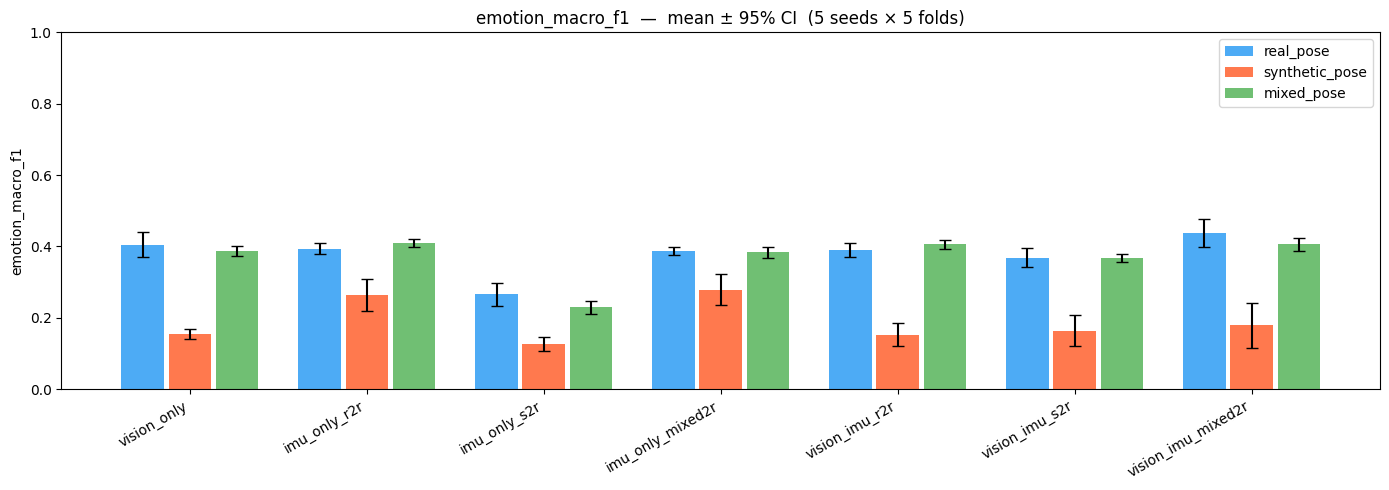

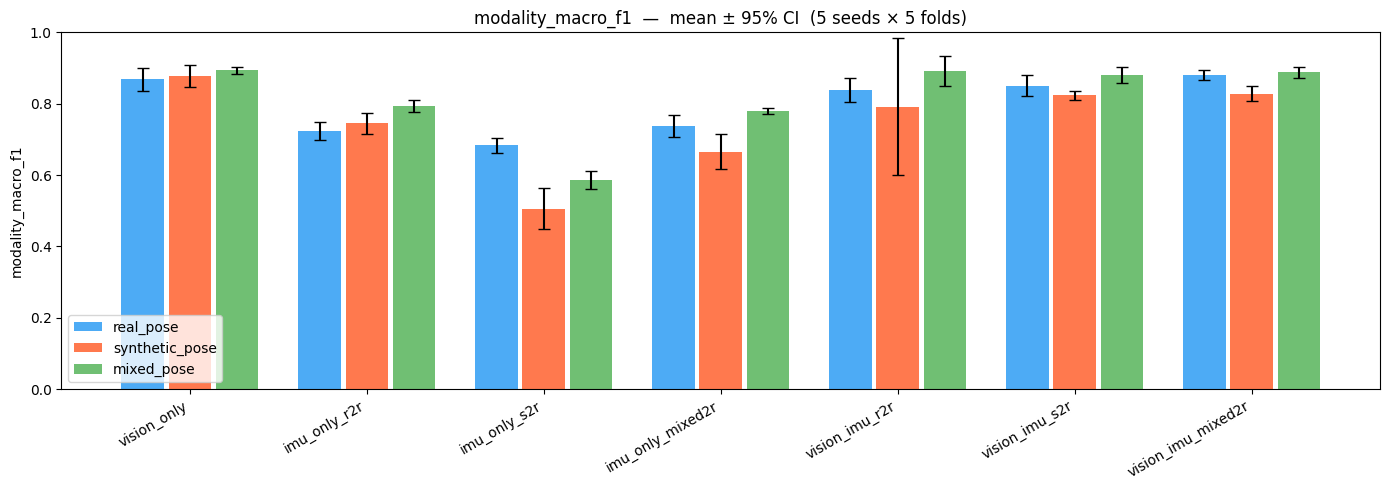

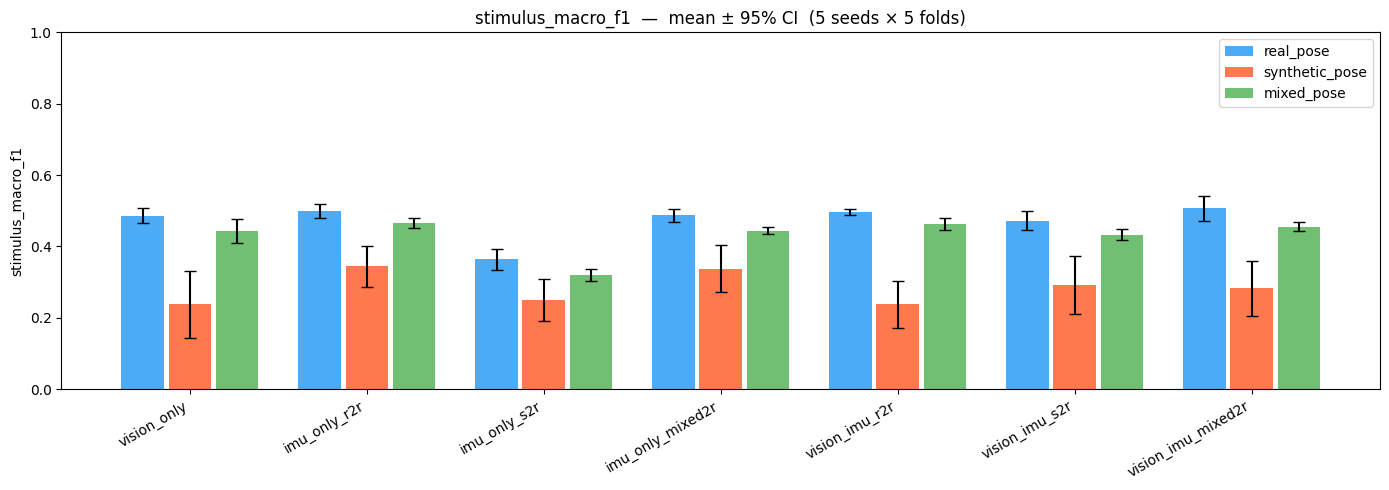

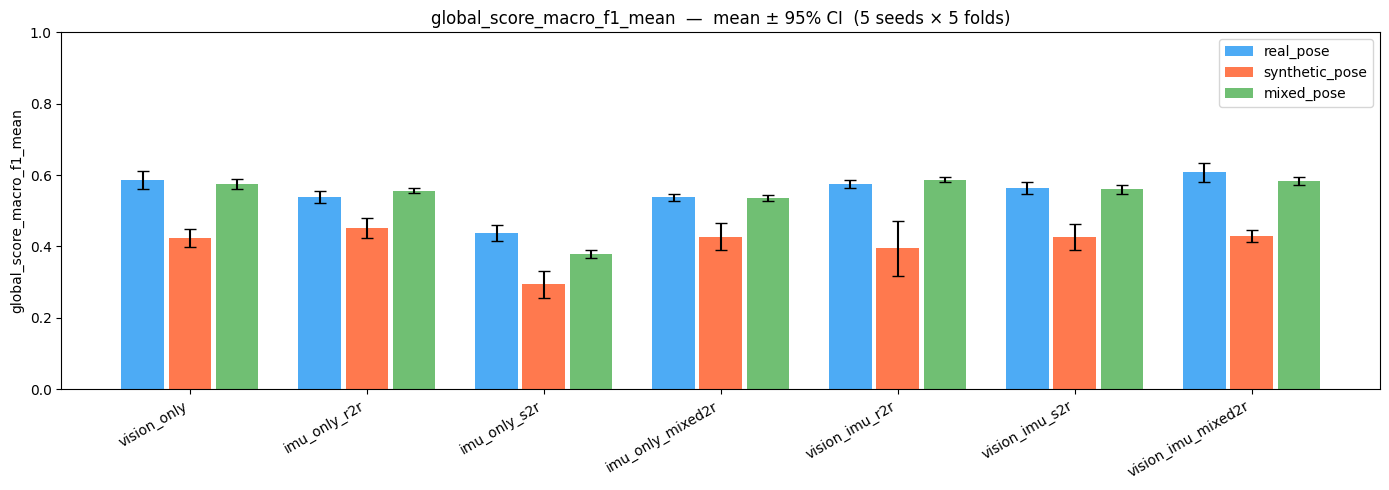

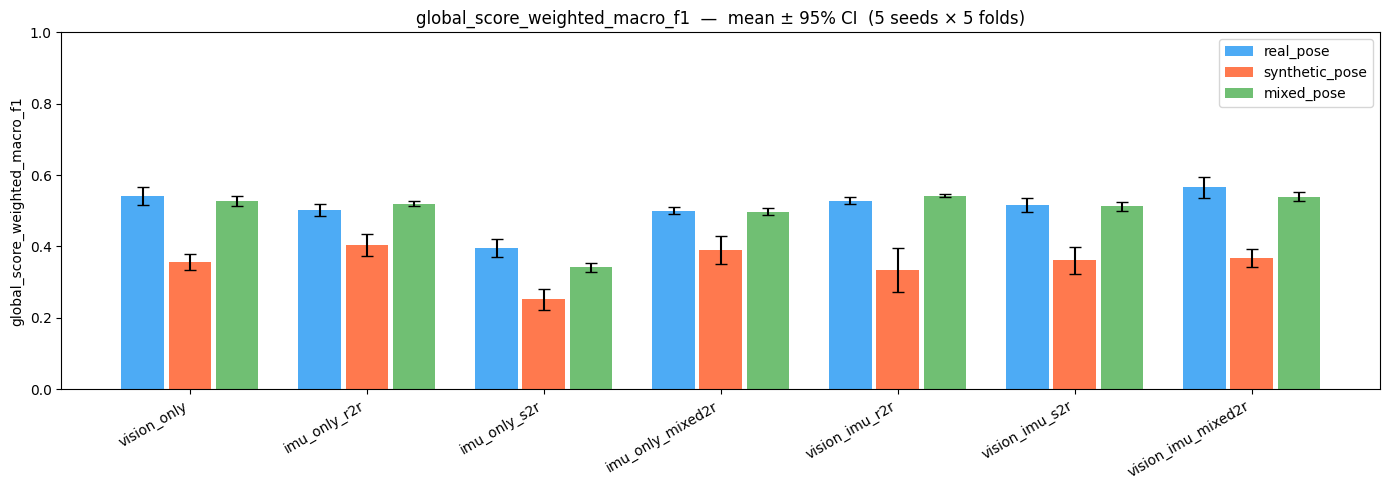

In [14]:
for metric in CI_METRICS:
    plot_ci_bar([REPEATED_REAL, REPEATED_SYNTHETIC, REPEATED_MIXED], metric=metric)

## Boxplots — distribution per seed


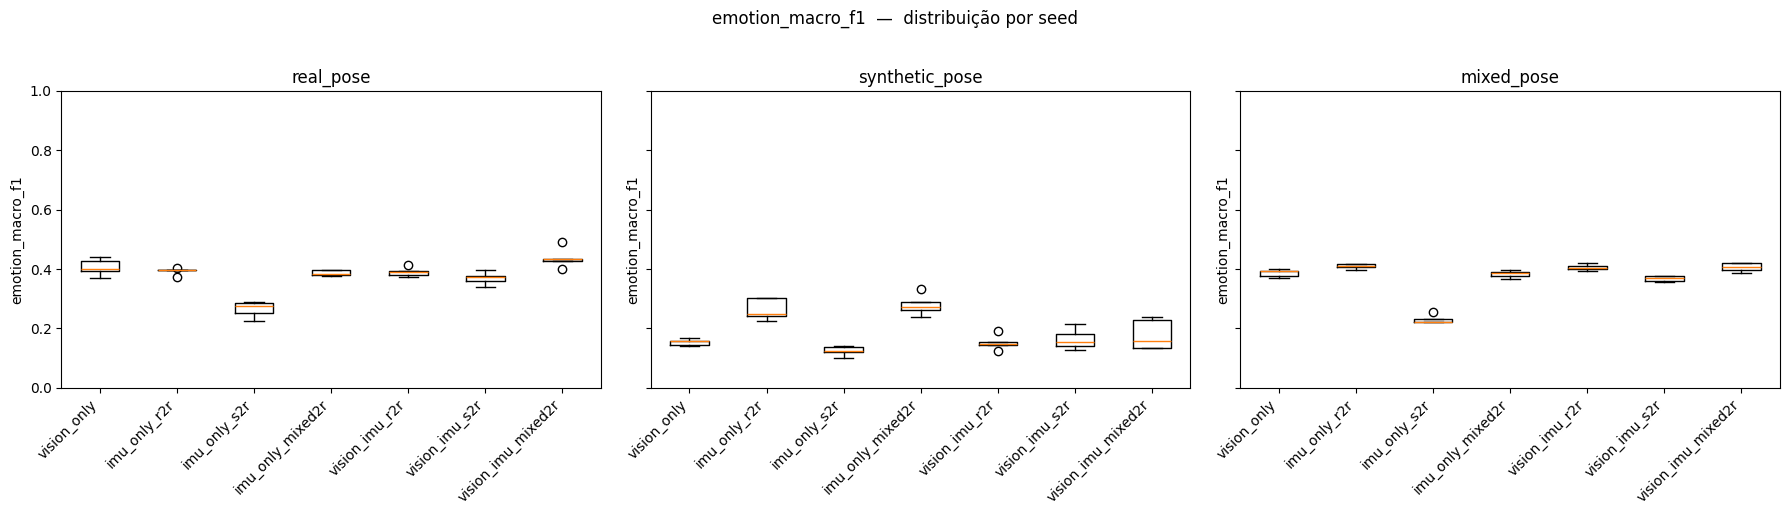

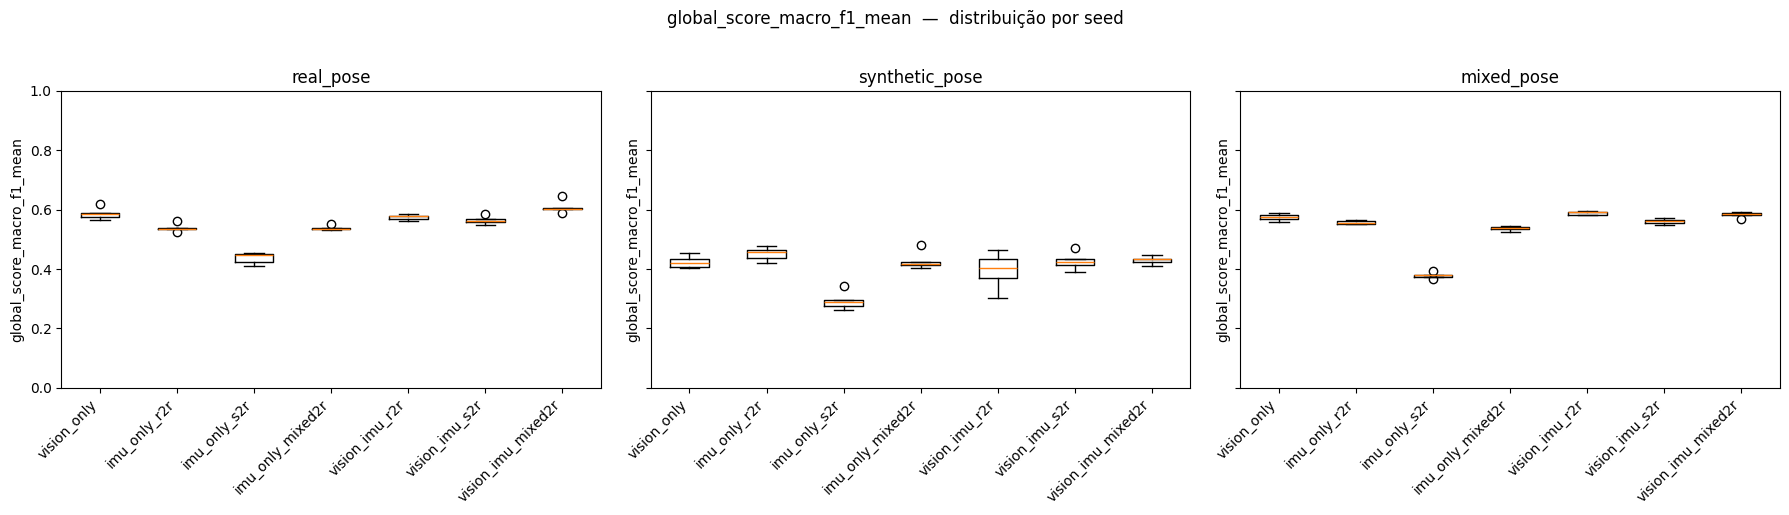

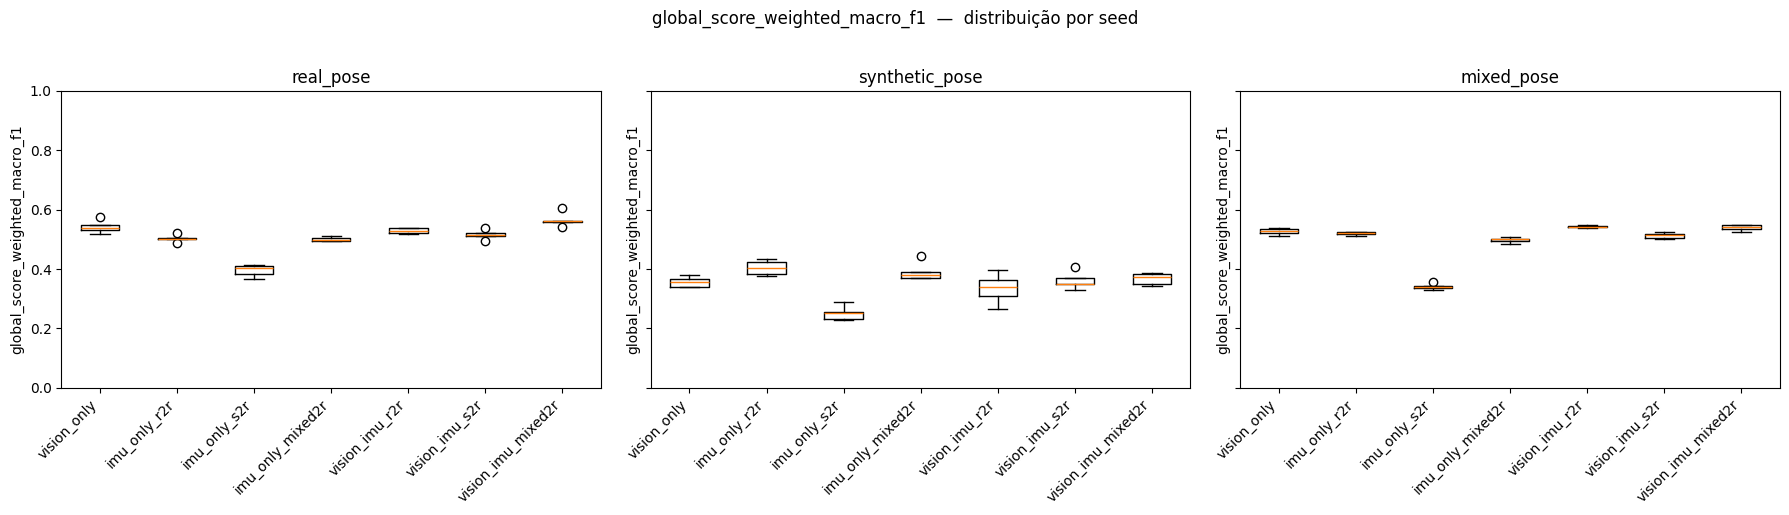

In [15]:
for metric in ['emotion_macro_f1', 'global_score_macro_f1_mean', 'global_score_weighted_macro_f1']:
    plot_seed_boxplot([REPEATED_REAL, REPEATED_SYNTHETIC, REPEATED_MIXED], metric=metric)

## Per-seed raw scores


In [16]:
metric = 'emotion_macro_f1'

for rr in (REPEATED_REAL, REPEATED_SYNTHETIC, REPEATED_MIXED):
    display(Markdown(f"### {rr['label']} — per-seed OOF `{metric}`"))
    rows = []
    for sr in rr['seed_results']:
        seed    = sr['seed']
        summary = sr['suite_result']['summary']
        for _, row in _sort_suite_summary(summary).iterrows():
            val = row.get(metric)
            rows.append({'seed': seed, 'experiment_name': row['experiment_name'], metric: val})
    pivot = pd.DataFrame(rows).pivot(index='experiment_name', columns='seed', values=metric)
    pivot.columns = [f'seed_{c}' for c in pivot.columns]
    pivot['mean'] = pivot.mean(axis=1).round(4)
    pivot['std']  = pivot.std(axis=1, ddof=1).round(4)
    display(pivot)

### real_pose — per-seed OOF `emotion_macro_f1`

,seed_42,seed_123,seed_456,seed_789,seed_1234,mean,std
experiment_name,,,,,,,
imu_only_mixed2r,0.376764,0.397686,0.380214,0.384761,0.397702,0.3874,0.0088
imu_only_r2r,0.396114,0.397914,0.404985,0.396677,0.371577,0.3935,0.0114
imu_only_s2r,0.274005,0.284970,0.290331,0.251972,0.226134,0.2655,0.0237
vision_imu_mixed2r,0.434228,0.427213,0.434613,0.489867,0.400989,0.4374,0.0290
vision_imu_r2r,0.390247,0.373463,0.391921,0.379097,0.414325,0.3898,0.0141
vision_imu_s2r,0.397798,0.358451,0.377652,0.338336,0.372795,0.3690,0.0199
vision_only,0.439395,0.369272,0.393836,0.425566,0.398676,0.4053,0.0247


### synthetic_pose — per-seed OOF `emotion_macro_f1`

,seed_42,seed_123,seed_456,seed_789,seed_1234,mean,std
experiment_name,,,,,,,
imu_only_mixed2r,0.262060,0.289017,0.331313,0.272586,0.238049,0.2786,0.0311
imu_only_r2r,0.242139,0.304116,0.225787,0.303400,0.247488,0.2646,0.0328
imu_only_s2r,0.142094,0.122191,0.125678,0.136268,0.101102,0.1255,0.0141
vision_imu_mixed2r,0.238431,0.134463,0.230147,0.136024,0.156336,0.1791,0.0458
vision_imu_r2r,0.122841,0.192484,0.148688,0.145804,0.155844,0.1531,0.0226
vision_imu_s2r,0.153571,0.180121,0.126593,0.141727,0.215983,0.1636,0.0315
vision_only,0.167557,0.144922,0.159112,0.140971,0.157818,0.1541,0.0098


### mixed_pose — per-seed OOF `emotion_macro_f1`

,seed_42,seed_123,seed_456,seed_789,seed_1234,mean,std
experiment_name,,,,,,,
imu_only_mixed2r,0.387033,0.366339,0.396743,0.376152,0.390477,0.3833,0.0108
imu_only_r2r,0.396218,0.411193,0.417876,0.417667,0.407681,0.4101,0.0080
imu_only_s2r,0.220653,0.253856,0.222894,0.220315,0.230936,0.2297,0.0127
vision_imu_mixed2r,0.397605,0.420518,0.386657,0.406027,0.420640,0.4063,0.0132
vision_imu_r2r,0.405061,0.411460,0.401602,0.421413,0.394472,0.4068,0.0091
vision_imu_s2r,0.359670,0.375536,0.370233,0.355358,0.376272,0.3674,0.0085
vision_only,0.378058,0.400048,0.391679,0.392034,0.371040,0.3866,0.0105
